# 03. Camera / Preprocess 검증 Runner

이 노트북의 질문은 단순함.

> Pi 카메라가 받은 `1296x972` 이미지를 CLRKDNet 입력인 `1x3x320x800` tensor로 빠르게 바꿀 수 있는가?

이 검증은 모델 정확도 검증이 아니다. 모델에 넣기 전 단계인 **카메라 capture + crop + resize + tensor 변환**이 병목인지 확인하는 실험이다.

Log 03에서 이 파트는 "모델을 보기 전에 입력 파이프라인부터 확인했다"는 흐름으로 들어가면 된다.

In [1]:
from pathlib import Path
import sys
import subprocess
import textwrap
import re
from IPython.display import Markdown, Image, display

ROOT = Path.cwd()
# Support both launch locations: architecture_validation/ and architecture_validation/notebooks/.
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif not (ROOT / 'scripts').exists() and (ROOT.parent / 'scripts').exists():
    ROOT = ROOT.parent
SCRIPTS = ROOT / 'scripts'
MODELS = ROOT / 'models'
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
print(f"validation root: {ROOT}")
print(f"scripts dir: {SCRIPTS}")
print(f"models dir: {MODELS}")
print(f"outputs dir: {OUTPUTS}")
print(f"python: {sys.executable}")

def show_lines(path, start=None, end=None):
    path = Path(path)
    lines = path.read_text(encoding="utf-8").splitlines()
    start = 1 if start is None else start
    end = len(lines) if end is None else end
    for lineno in range(start, min(end, len(lines)) + 1):
        print(f"{lineno:04d}: {lines[lineno - 1]}")

def run_cmd(args, check=False):
    print("$ " + " ".join(str(a) for a in args))
    result = subprocess.run(args, text=True, capture_output=True, cwd=str(ROOT))
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print("[stderr]")
        print(result.stderr)
    if check and result.returncode != 0:
        raise RuntimeError(f"command failed with code {result.returncode}")
    print(f"returncode={result.returncode}")
    return result

SCRIPT = SCRIPTS / '02_camera_preprocess_bench.py'
assert SCRIPT.exists(), SCRIPT
print(SCRIPT)

validation root: /home/pi/AI_CAR/architecture_validation/lane_model
scripts dir: /home/pi/AI_CAR/architecture_validation/lane_model/scripts
models dir: /home/pi/AI_CAR/architecture_validation/lane_model/models
outputs dir: /home/pi/AI_CAR/architecture_validation/lane_model/outputs
python: /home/pi/AI_CAR/env/bin/python3
/home/pi/AI_CAR/architecture_validation/lane_model/scripts/02_camera_preprocess_bench.py


## 코드 읽기 1 — CLRKDNet 입력 크기로 바꾸는 부분

`preprocess_frame()`은 카메라 frame을 CLRKDNet 입력 형태로 바꾼다.

핵심은 세 가지다.

1. Picamera2가 주는 RGB frame을 OpenCV 스타일 BGR로 바꿈.
2. CLRKDNet의 CULane 전처리 비율에 맞춰 위쪽을 crop함.
3. 최종적으로 `(1, 3, 320, 800)` tensor를 만듦.

In [2]:
show_lines(SCRIPT, 17, 41)

0017: import numpy as np
0018: 
0019: 
0020: DEFAULT_CROP_RATIO = 270 / 590
0021: 
0022: 
0023: def preprocess_frame(
0024:     frame: np.ndarray,
0025:     input_width: int,
0026:     input_height: int,
0027:     crop_top: int | None,
0028:     color_order: str,
0029: ) -> tuple[np.ndarray, int]:
0030:     if color_order == "rgb":
0031:         frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
0032: 
0033:     h, _ = frame.shape[:2]
0034:     actual_crop_top = int(round(h * DEFAULT_CROP_RATIO)) if crop_top is None else crop_top
0035:     actual_crop_top = min(max(actual_crop_top, 0), max(0, h - 1))
0036:     cropped = frame[actual_crop_top:, :, :]
0037:     resized = cv2.resize(cropped, (input_width, input_height), interpolation=cv2.INTER_LINEAR)
0038:     tensor = resized.astype(np.float32).transpose(2, 0, 1)[None, ...]
0039:     return tensor, actual_crop_top
0040: 
0041: 


## 코드 읽기 2 — 측정하는 값

이 스크립트는 capture 시간과 preprocess 시간을 따로 잰다.

그래야 병목이 카메라 쪽인지, resize/tensor 변환 쪽인지 분리해서 볼 수 있다.

In [3]:
show_lines(SCRIPT, 86, 133)

0086:         source: int | str = int(args.source) if args.source.isdigit() else args.source
0087:         capture = cv2.VideoCapture(source)
0088:         capture.set(cv2.CAP_PROP_FRAME_WIDTH, args.width)
0089:         capture.set(cv2.CAP_PROP_FRAME_HEIGHT, args.height)
0090:         if not capture.isOpened():
0091:             raise RuntimeError(f"Could not open source: {args.source}")
0092: 
0093:     try:
0094:         total_start = time.perf_counter()
0095:         for idx in range(args.frames + args.warmup):
0096:             t0 = time.perf_counter()
0097:             if camera is not None:
0098:                 frame = camera.capture_array()
0099:             else:
0100:                 ok, frame = capture.read()
0101:                 if not ok:
0102:                     raise RuntimeError("Failed to read frame")
0103:             t1 = time.perf_counter()
0104:             if not args.no_flip_180:
0105:                 frame = cv2.flip(frame, -1)
0106: 
0107:             tensor,

## 실행

Pi에서 실행할 때는 반드시 `architecture validation` 폴더에서 실행한다.

아래 셀은 현재 노트북 kernel의 Python으로 스크립트를 실행한다. Pi에서 Jupyter를 `env` 안에서 켰다면 `sys.executable`이 `/home/pi/AI_CAR/env/bin/python3`이어야 한다.

In [4]:
cmd = [
    sys.executable, str(SCRIPT),
    "--frames", "200",
    "--warmup", "20",
    "--save-preview", str(OUTPUTS / "camera_preprocess_preview.jpg"),
]
result = run_cmd(cmd)

$ /home/pi/AI_CAR/env/bin/python3 /home/pi/AI_CAR/architecture_validation/lane_model/scripts/02_camera_preprocess_bench.py --frames 200 --warmup 20 --save-preview /home/pi/AI_CAR/architecture_validation/lane_model/outputs/camera_preprocess_preview.jpg
resolution: 1296x972
flip_180: True
crop_top: 445
final_input_shape: (1, 3, 320, 800)
frames_measured: 200
end_to_end_loop_fps: 27.37
capture_ms_mean: 27.31
capture_ms_p95: 27.56
preprocess_ms_mean: 6.01
preprocess_ms_p95: 6.69
saved_preview: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/camera_preprocess_preview.jpg

[stderr]
[1:45:31.860998521] [3329]  INFO Camera camera_manager.cpp:340 libcamera v0.6.0+rpt20251202
[1:45:31.869361798] [3335]  INFO RPI pisp.cpp:720 libpisp version 1.3.0
[1:45:31.871708891] [3335]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/ov5647.json
[1:45:31.878601132] [3335]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/

## Raw / Preprocess 비교 이미지

포스팅에 사용할 수 있도록 같은 순간의 카메라 프레임을 두 가지 형태로 저장하고 보여준다.

중요: OpenCV는 기본적으로 BGR 순서를 쓰고, Notebook/PIL/브라우저 이미지는 RGB로 해석한다. 그래서 포스팅용 preview 이미지는 `cv2.imwrite` 대신 PIL로 RGB 배열을 그대로 저장한다. 이렇게 해야 빨간색이 파란색으로 뒤집히지 않는다.

- `02_raw_camera_frame.jpg`: Pi camera 원본 프레임. 단, 실제 주행 기준에 맞게 180도 flip은 적용함.
- `02_raw_camera_frame_crop_line.jpg`: 원본 프레임 위에 crop 시작선을 표시한 이미지.
- `02_preprocess_preview.jpg`: CLRKDNet 입력 영역을 사람이 보기 쉬운 RGB 이미지로 저장한 `800x320` preview.

아래 셀은 카메라를 한 번 다시 열어서 새 프레임을 저장한다. 카메라가 busy라고 나오면 이전 카메라 셀이 완전히 끝났는지 확인하거나 kernel을 restart한 뒤 다시 실행함.


[1:45:41.047915663] [3315]  INFO Camera camera_manager.cpp:340 libcamera v0.6.0+rpt20251202
[1:45:41.056258626] [3349]  INFO RPI pisp.cpp:720 libpisp version 1.3.0
[1:45:41.058647978] [3349]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/ov5647.json
[1:45:41.065344256] [3349]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36' for pipeline handler rpi/pisp
[1:45:41.065358552] [3349]  INFO RPI pisp.cpp:1181 Registered camera /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 to CFE device /dev/media0 and ISP device /dev/media2 using PiSP variant BCM2712_C0
[1:45:41.068779034] [3315]  INFO Camera camera.cpp:1215 configuring streams: (0) 1296x972-RGB888/Rec709/Rec709/None/Full (1) 1296x972-GBRG_PISP_COMP1/RAW
[1:45:41.068871922] [3349]  INFO RPI pisp.cpp:1485 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 - Selected sensor format: 1296x972-SGBRG10_1X10/RAW - Selected CFE format: 1296x972-PC1g

raw_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/02_raw_camera_frame.jpg
raw_crop_line_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/02_raw_camera_frame_crop_line.jpg
preprocess_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/02_preprocess_preview.jpg
crop_top: 445
model_tensor_shape: (1, 3, 320, 800)
note: saved preview images use RGB order to avoid red/blue channel swap


**Pi camera raw frame + crop boundary**

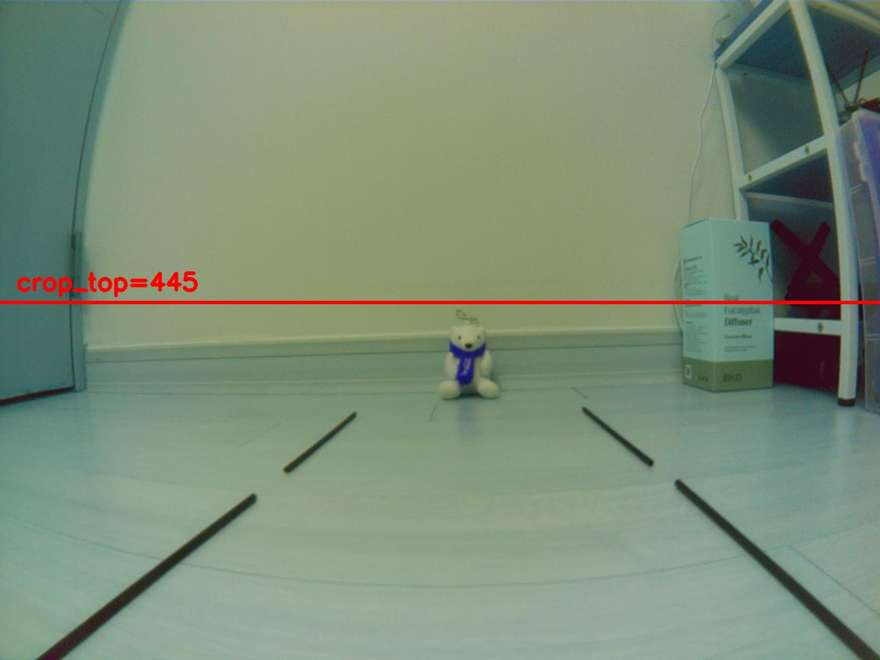

**CLRKDNet preprocess preview: crop + resize → 800x320**

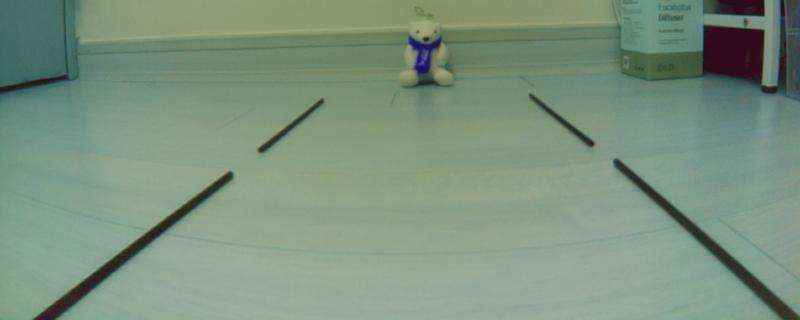

In [5]:
from IPython.display import display, Image, Markdown
from PIL import Image as PILImage
import importlib.util
import time
import cv2

spec = importlib.util.spec_from_file_location("camera_preprocess_bench", SCRIPT)
bench = importlib.util.module_from_spec(spec)
spec.loader.exec_module(bench)

raw_path = OUTPUTS / "02_raw_camera_frame.jpg"
raw_crop_line_path = OUTPUTS / "02_raw_camera_frame_crop_line.jpg"
preprocess_path = OUTPUTS / "02_preprocess_preview.jpg"

from picamera2 import Picamera2

camera = Picamera2()
config = camera.create_video_configuration(main={"size": (1296, 972), "format": "RGB888"})
camera.configure(config)
camera.start()
time.sleep(1.0)
try:
    frame_rgb = camera.capture_array()
finally:
    camera.stop()

# Camera is mounted upside down on the car, so all camera-based validation uses 180-degree flip by default.
# Keep this array in RGB order for notebook/blog images.
frame_rgb = cv2.flip(frame_rgb, -1)

# Save the corrected raw camera frame as an RGB image.
PILImage.fromarray(frame_rgb).save(raw_path)

# Run the same preprocessing path used by the benchmark script to verify tensor shape/crop_top.
tensor, crop_top = bench.preprocess_frame(
    frame_rgb,
    input_width=800,
    input_height=320,
    crop_top=None,
    color_order="rgb",
)

# Save raw frame with crop boundary in RGB order.
raw_crop_line_rgb = frame_rgb.copy()
cv2.line(raw_crop_line_rgb, (0, crop_top), (raw_crop_line_rgb.shape[1] - 1, crop_top), (255, 0, 0), 4)
cv2.putText(
    raw_crop_line_rgb,
    f"crop_top={crop_top}",
    (24, max(48, crop_top - 18)),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.2,
    (255, 0, 0),
    3,
    cv2.LINE_AA,
)
PILImage.fromarray(raw_crop_line_rgb).save(raw_crop_line_path)

# Human-readable preprocess preview: crop + resize in RGB order.
# The model tensor may use a BGR-like channel order internally, but blog preview should preserve real colors.
preprocess_rgb = cv2.resize(frame_rgb[crop_top:, :, :], (800, 320), interpolation=cv2.INTER_LINEAR)
PILImage.fromarray(preprocess_rgb).save(preprocess_path)

print(f"raw_path: {raw_path}")
print(f"raw_crop_line_path: {raw_crop_line_path}")
print(f"preprocess_path: {preprocess_path}")
print(f"crop_top: {crop_top}")
print(f"model_tensor_shape: {tensor.shape}")
print("note: saved preview images use RGB order to avoid red/blue channel swap")

display(Markdown("**Pi camera raw frame + crop boundary**"))
display(Image(filename=str(raw_crop_line_path), width=720))
display(Markdown("**CLRKDNet preprocess preview: crop + resize → 800x320**"))
display(Image(filename=str(preprocess_path), width=720))


fixed_raw_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/02_raw_camera_frame_color_fixed.jpg
fixed_crop_line_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/02_raw_camera_frame_crop_line_color_fixed.jpg
fixed_preprocess_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/02_preprocess_preview_color_fixed.jpg
note: 이 셀의 출력에서 빨간 목도리가 정상적으로 빨간색이면, 포스팅에는 *_color_fixed.jpg 파일을 사용하면 됨


**Color fixed raw frame + crop boundary**

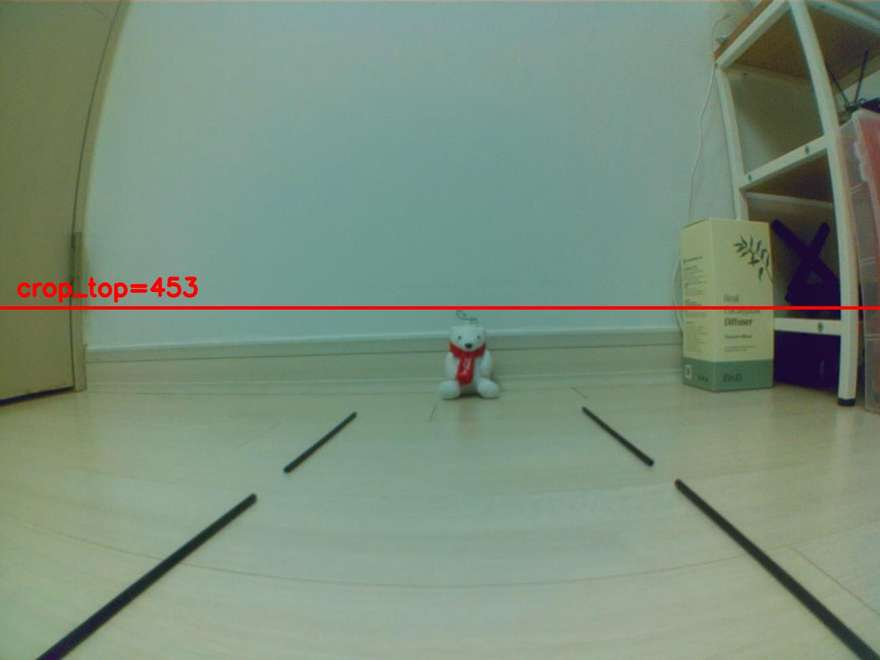

**Color fixed CLRKDNet preprocess preview**

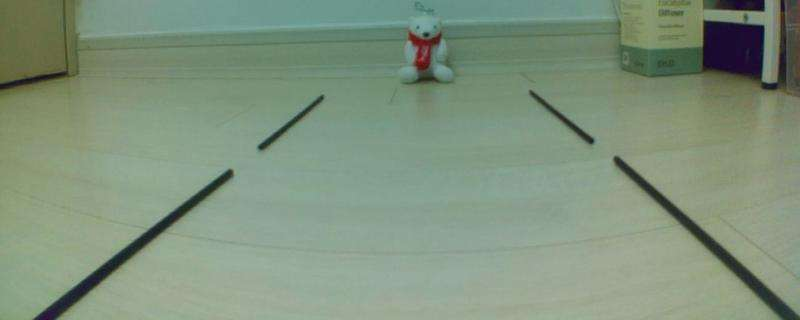

In [1]:
# 색상 채널 보정 확인
# 현재 Pi camera -> OpenCV/PIL 표시 경로에서 빨간색이 파란색으로 보이면 R/B 채널이 뒤집힌 상태다.
# 이 셀은 직전 셀에서 저장한 raw 이미지를 기준으로 R/B 채널을 보정한 preview를 새 파일로 저장하고 표시한다.

from pathlib import Path
import numpy as np
import cv2
from PIL import Image as PILImage
from IPython.display import display, Image, Markdown

try:
    OUTPUTS
except NameError:
    ROOT = Path('/home/pi/AI_CAR/architecture_validation/lane_model')
    OUTPUTS = ROOT / 'outputs'

source_raw_path = OUTPUTS / '02_raw_camera_frame.jpg'
assert source_raw_path.exists(), f'먼저 Raw / Preprocess 비교 이미지 셀을 실행해야 함: {source_raw_path}'

# PIL로 읽은 이미지는 RGB로 해석되지만, 현재 저장본에서 red/blue가 뒤집혀 보였으므로 R/B 채널을 교환한다.
raw_display_wrong = np.array(PILImage.open(source_raw_path).convert('RGB'))
raw_rgb_fixed = raw_display_wrong[:, :, [2, 1, 0]].copy()

try:
    crop_top
except NameError:
    # 1296x972 -> 800x320 입력을 만들 때 아래쪽 320/800 비율 영역을 쓰도록 crop_top을 재계산한다.
    crop_top = int(raw_rgb_fixed.shape[0] - raw_rgb_fixed.shape[1] * (320 / 800))
    crop_top = max(0, min(crop_top, raw_rgb_fixed.shape[0] - 1))

fixed_raw_path = OUTPUTS / '02_raw_camera_frame_color_fixed.jpg'
fixed_crop_line_path = OUTPUTS / '02_raw_camera_frame_crop_line_color_fixed.jpg'
fixed_preprocess_path = OUTPUTS / '02_preprocess_preview_color_fixed.jpg'

PILImage.fromarray(raw_rgb_fixed).save(fixed_raw_path)

raw_crop_line_rgb = raw_rgb_fixed.copy()
cv2.line(raw_crop_line_rgb, (0, crop_top), (raw_crop_line_rgb.shape[1] - 1, crop_top), (255, 0, 0), 4)
cv2.putText(
    raw_crop_line_rgb,
    f'crop_top={crop_top}',
    (24, max(48, crop_top - 18)),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.2,
    (255, 0, 0),
    3,
    cv2.LINE_AA,
)
PILImage.fromarray(raw_crop_line_rgb).save(fixed_crop_line_path)

preprocess_rgb_fixed = cv2.resize(raw_rgb_fixed[crop_top:, :, :], (800, 320), interpolation=cv2.INTER_LINEAR)
PILImage.fromarray(preprocess_rgb_fixed).save(fixed_preprocess_path)

print(f'fixed_raw_path: {fixed_raw_path}')
print(f'fixed_crop_line_path: {fixed_crop_line_path}')
print(f'fixed_preprocess_path: {fixed_preprocess_path}')
print('note: 이 셀의 출력에서 빨간 목도리가 정상적으로 빨간색이면, 포스팅에는 *_color_fixed.jpg 파일을 사용하면 됨')

display(Markdown('**Color fixed raw frame + crop boundary**'))
display(Image(filename=str(fixed_crop_line_path), width=720))
display(Markdown('**Color fixed CLRKDNet preprocess preview**'))
display(Image(filename=str(fixed_preprocess_path), width=720))


## 02 검증 메모

이번 검증의 질문은 **Pi 카메라가 CLRKDNet 입력을 만들 만큼 충분히 빠른가**였음.

노트북에서 먼저 실행된 결과는 아래와 같았음.

```text
resolution: 1296x972
crop_top: 445
final_input_shape: (1, 3, 320, 800)
frames_measured: 200
end_to_end_loop_fps: 27.40
capture_ms_mean: 30.83
capture_ms_p95: 31.29
preprocess_ms_mean: 2.50
preprocess_ms_p95: 2.73
```

이 결과만 보면 camera capture + crop/resize/tensor 변환은 약 `27.4fps`로 동작함. CLRKDNet 입력 shape인 `(1, 3, 320, 800)`도 정상적으로 만들어짐. 따라서 현재 단계에서 카메라 전처리는 큰 병목이 아님.

다만 preview를 확인했을 때 이미지가 180도 뒤집혀 있었음. 실제 주행에서는 차선, 표지판, 신호등의 위치 해석이 전부 뒤집히므로, 모든 camera 기반 검증 스크립트에 기본 180도 flip을 반영함.

적용한 기본 동작:

```python
frame = cv2.flip(frame, -1)
```

필요하면 `--no-flip-180` 옵션으로 끌 수 있게 해둠.

flip 반영 후 같은 02번 스크립트를 다시 실행한 결과는 아래와 같았음.

```text
resolution: 1296x972
flip_180: True
crop_top: 445
final_input_shape: (1, 3, 320, 800)
frames_measured: 200
end_to_end_loop_fps: 27.39
capture_ms_mean: 27.67
capture_ms_p95: 28.31
preprocess_ms_mean: 5.66
preprocess_ms_p95: 6.19
```

flip이 추가되면서 preprocess 평균 시간이 약 `2.50ms`에서 `5.66ms`로 늘었지만, 전체 loop는 여전히 약 `27fps`임. 즉 180도 보정까지 포함해도 카메라 전처리는 실시간 제어 관점에서 충분히 빠름.

판단:

```text
02_camera_preprocess 검증 통과.
카메라 해상도 1296x972 유지.
CLRKDNet 입력 800x320 생성 정상.
180도 flip 기본 적용 필요.
다음 병목 후보는 카메라가 아니라 CLRKDNet ONNX 추론 속도.
```

따라서 다음 검증은 `03_lane_onnx_bench.py`로 넘어가서, thread 수별 ONNX inference FPS를 확인하면 됨.
